<a href="https://colab.research.google.com/github/lolaglezc13-png/Examen-E2/blob/main/Examen_E2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Librerías cargadas correctamente

SISTEMA AIR-GUARD: Red de Vigilancia Atmosférica
CONFIGURACIÓN DE ACCESO A AEMET

📋 Para obtener tu API Key:
   1. Ve a [opendata.aemet.es](https://opendata.aemet.es)
   2. Haz clic en 'Obtención de API Key'
   3. Introduce tu email y recibirás la clave

⬇️ Pega tu API Key en la caja que aparece abajo:
Tu API Key de AEMET: ··········

✅ API Key introducida correctamente
   Longitud: 285 caracteres

📡 Conectando con AEMET OpenData...
   📍 Estación: C449C (Santa Cruz de Tenerife)
   📅 Período: 16/03/2026 - 15/04/2026

❌ Error de conexión: No connection adapters were found for '[opendata.aemet.es](https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2026-03-16T00:00:00UTC/fechafin/2026-04-15T23:59:59UTC/estacion/C449C)'

CREACIÓN DEL DATASET AIR-GUARD

🌿 Generando 250 registros de AIRE LIMPIO...
🏜️ Generando 125 registros de EPISODIO DE CALIMA...
🚗 Generando 125 registros de POLUCIÓN URBANA...

⚠️ Añadiendo datos ruidosos

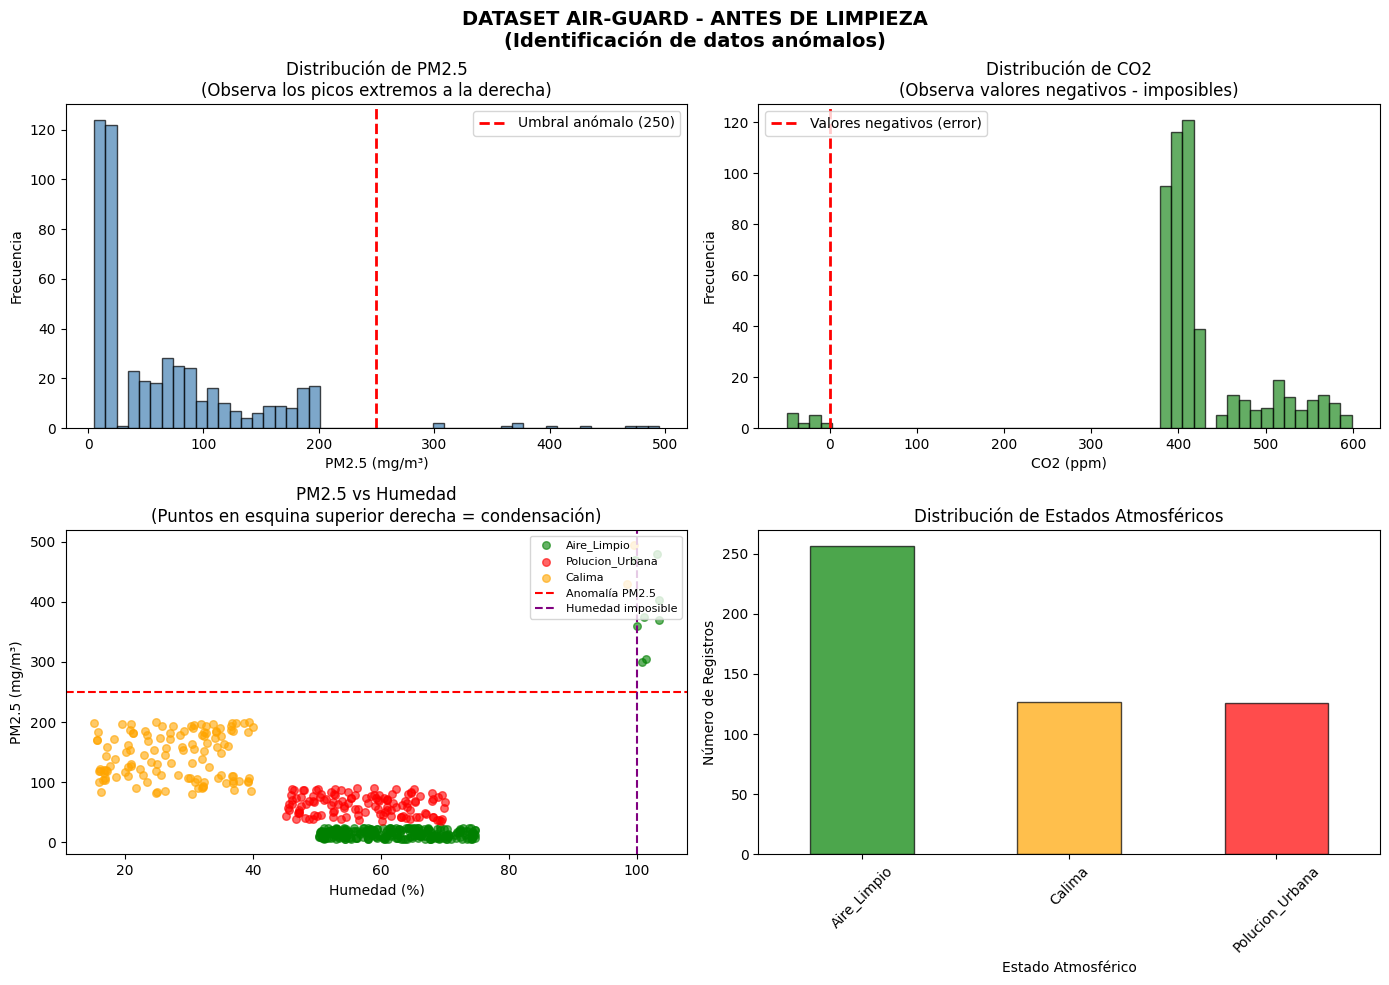


💾 Gráfico guardado como: 01_exploracion_antes_limpieza.png

LIMPIEZA CRÍTICA DEL DATASET

📋 Registros originales: 510

🔧 Limpieza 1: CO2 negativos (fallo de sensor)
   Registros eliminados: 18
   Justificación: El CO2 atmosférico nunca puede ser negativo.
                  Valores negativos indican mal funcionamiento del sensor.

🔧 Limpieza 2: Condensación en sensor óptico
   Registros eliminados: 10
   Justificación: Los sensores ópticos de PM2.5 dan lecturas falsas
                  cuando hay condensación (humedad extrema > 95%).

🔧 Limpieza 3: Valores nulos
   Registros eliminados: 4
   Justificación: Registros incompletos no son útiles para entrenamiento.

🔧 Limpieza 4: Registros duplicados
   Registros eliminados: 0
   Justificación: Los duplicados sesgan el modelo hacia ciertos patrones.

----------------------------------------
📊 RESUMEN DE LIMPIEZA:
----------------------------------------
   Registros originales:  510
   Registros eliminados:  32 (6.3%)
   Registros finales:

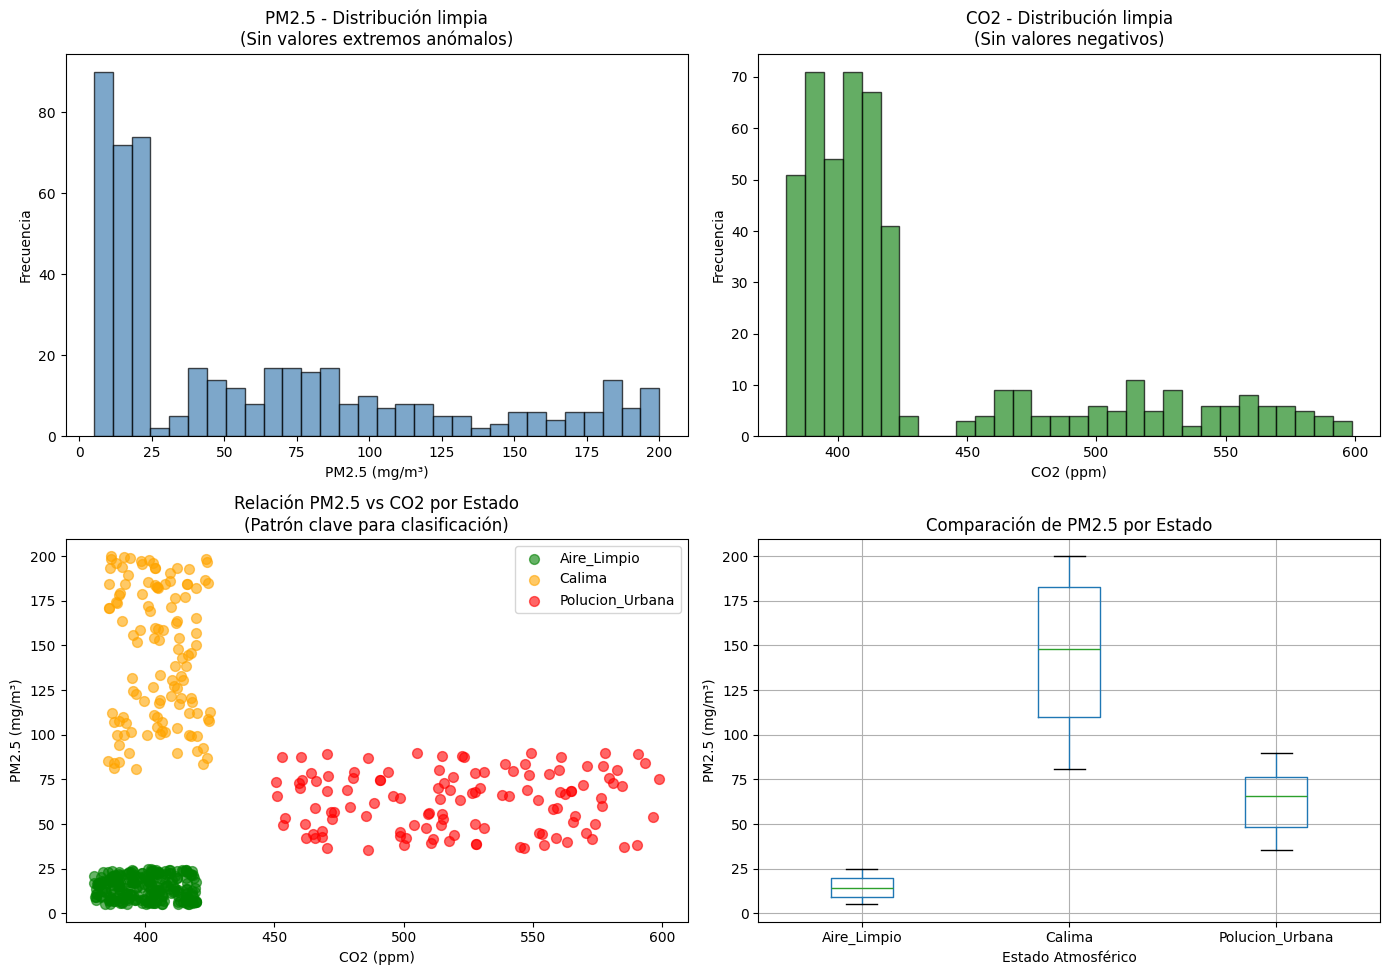


💾 Gráfico guardado como: 02_dataset_limpio.png

BLOQUE 2: PREPARACIÓN PARA EL ENTRENAMIENTO

📋 Preparación de datos:
   Características utilizadas: ['PM2.5_mg_m3', 'CO2_ppm', 'Humedad_%', 'Temperatura_C']
   Clases a predecir: ['Aire_Limpio', 'Calima', 'Polucion_Urbana']
   Total de muestras: 478

📊 División de datos (70% entrenamiento / 30% prueba):
   Entrenamiento: 334 muestras
   Prueba: 144 muestras

✅ Datos normalizados y listos para entrenamiento

ENTRENAMIENTO: RANDOM FOREST

🌲 ¿Qué es Random Forest?
   Es un algoritmo que crea múltiples 'árboles de decisión'
   y combina sus votos para hacer la predicción final.
   Es robusto y funciona bien con datos de sensores.

⏳ Entrenando modelo...
✅ Modelo entrenado

📊 Precisión del modelo: 100.00%

🔍 Importancia de cada característica:
   PM2.5_mg_m3     0.464 ███████████████████████
   CO2_ppm         0.260 ████████████
   Humedad_%       0.249 ████████████
   Temperatura_C   0.027 █

ENTRENAMIENTO: RED NEURONAL SIMPLE (MLP)

🧠 ¿Qué 

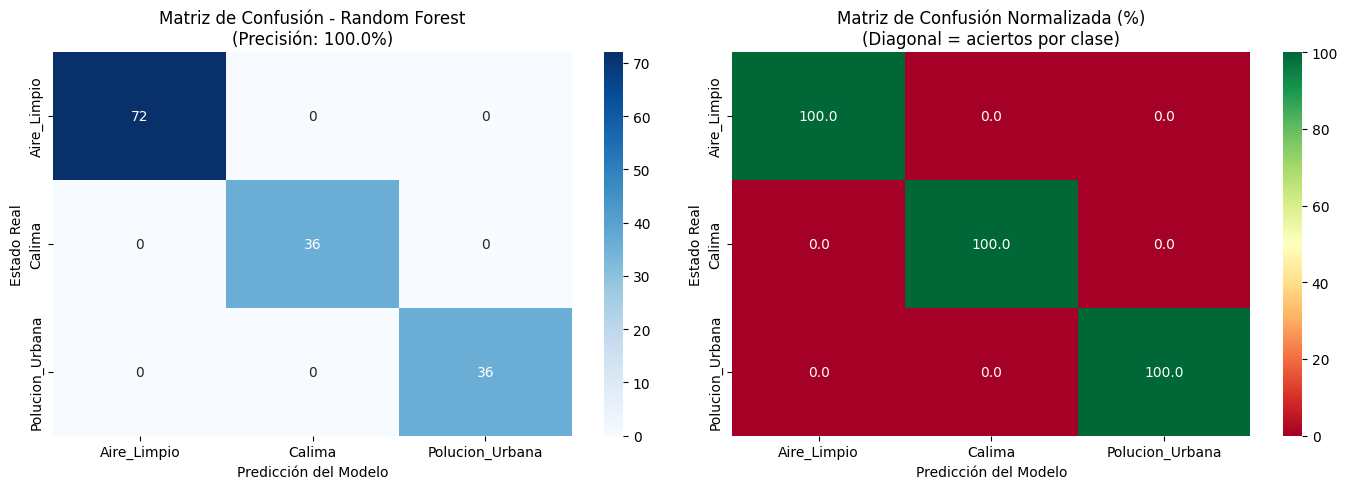


💾 Gráfico guardado como: 03_matriz_confusion.png

MATRIZ DE CONFUSIÓN - ANÁLISIS DE ERRORES

📊 Modelo evaluado: Random Forest

📋 Reporte de clasificación:
                 precision    recall  f1-score   support

    Aire_Limpio       1.00      1.00      1.00        72
         Calima       1.00      1.00      1.00        36
Polucion_Urbana       1.00      1.00      1.00        36

       accuracy                           1.00       144
      macro avg       1.00      1.00      1.00       144
   weighted avg       1.00      1.00      1.00       144


⚠️ ANÁLISIS DE ERRORES CRÍTICOS (Falsos Negativos):
--------------------------------------------------
   Calima clasificado como Aire_Limpio: 0 casos
   Polucion_Urbana clasificado como Aire_Limpio: 0 casos


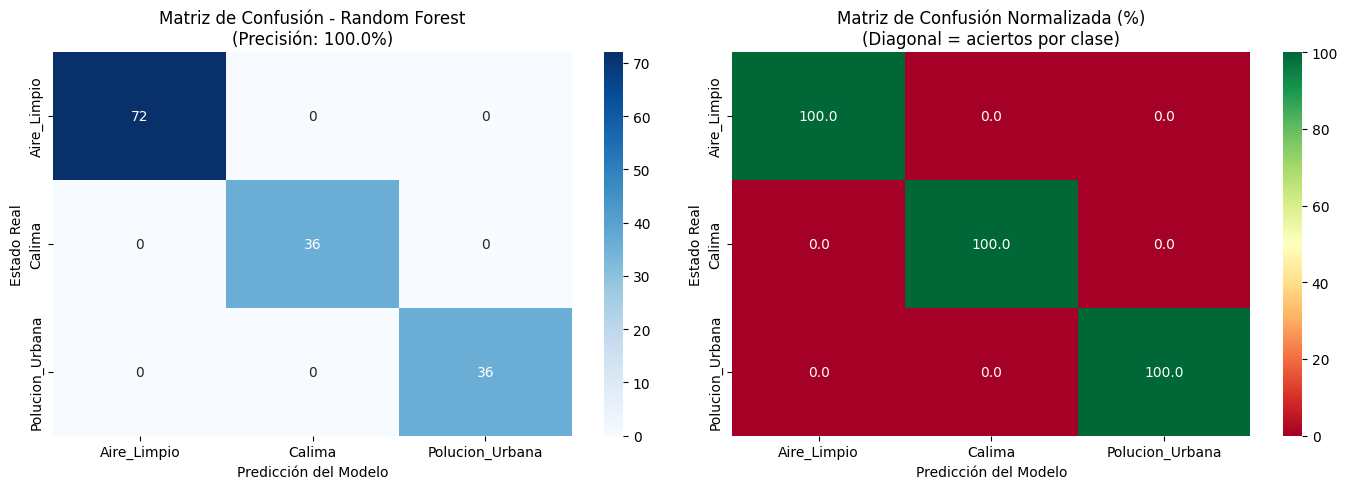


💾 Gráfico guardado como: 03_matriz_confusion.png

BLOQUE 3: TEST DE ESTRÉS CON CASOS FRONTERA

🎯 ¿Qué son los casos 'frontera'?
   Son situaciones ambiguas donde las características se solapan
   entre diferentes estados. Sirven para evaluar la robustez del modelo.

📋 CASOS FRONTERA PARA TEST:
----------------------------------------------------------------------
                       Caso  PM2.5_mg_m3  CO2_ppm  Humedad_%  Temperatura_C                  Estado_esperado
1. Calima suave o polución?           75      430         35             30      Ambiguo (Calima o Polución)
      2. Aire limpio límite           28      415         72             22 Ambiguo (Limpio o Polución leve)
       3. Polución nocturna           55      520         55             20                  Polución Urbana
       4. Pre-calima dudoso           85      400         28             33                           Calima
    5. Tráfico intenso seco           70      480         32             28 Ambiguo (Pol

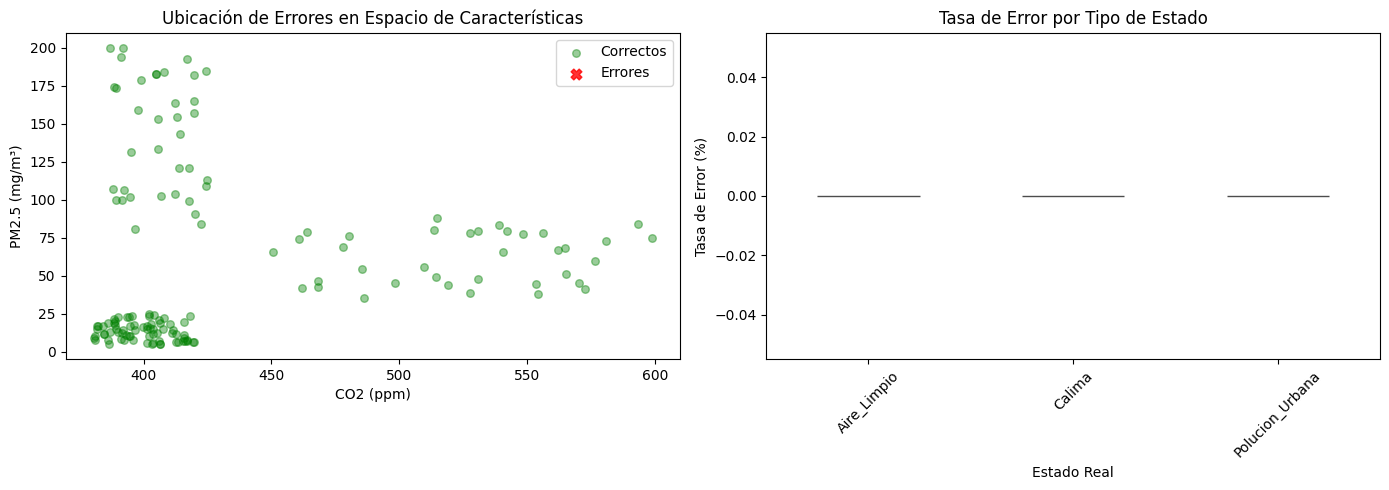


💾 Gráfico guardado como: 04_analisis_errores.png

BLOQUE 4: GENERACIÓN DEL DASHBOARD FINAL


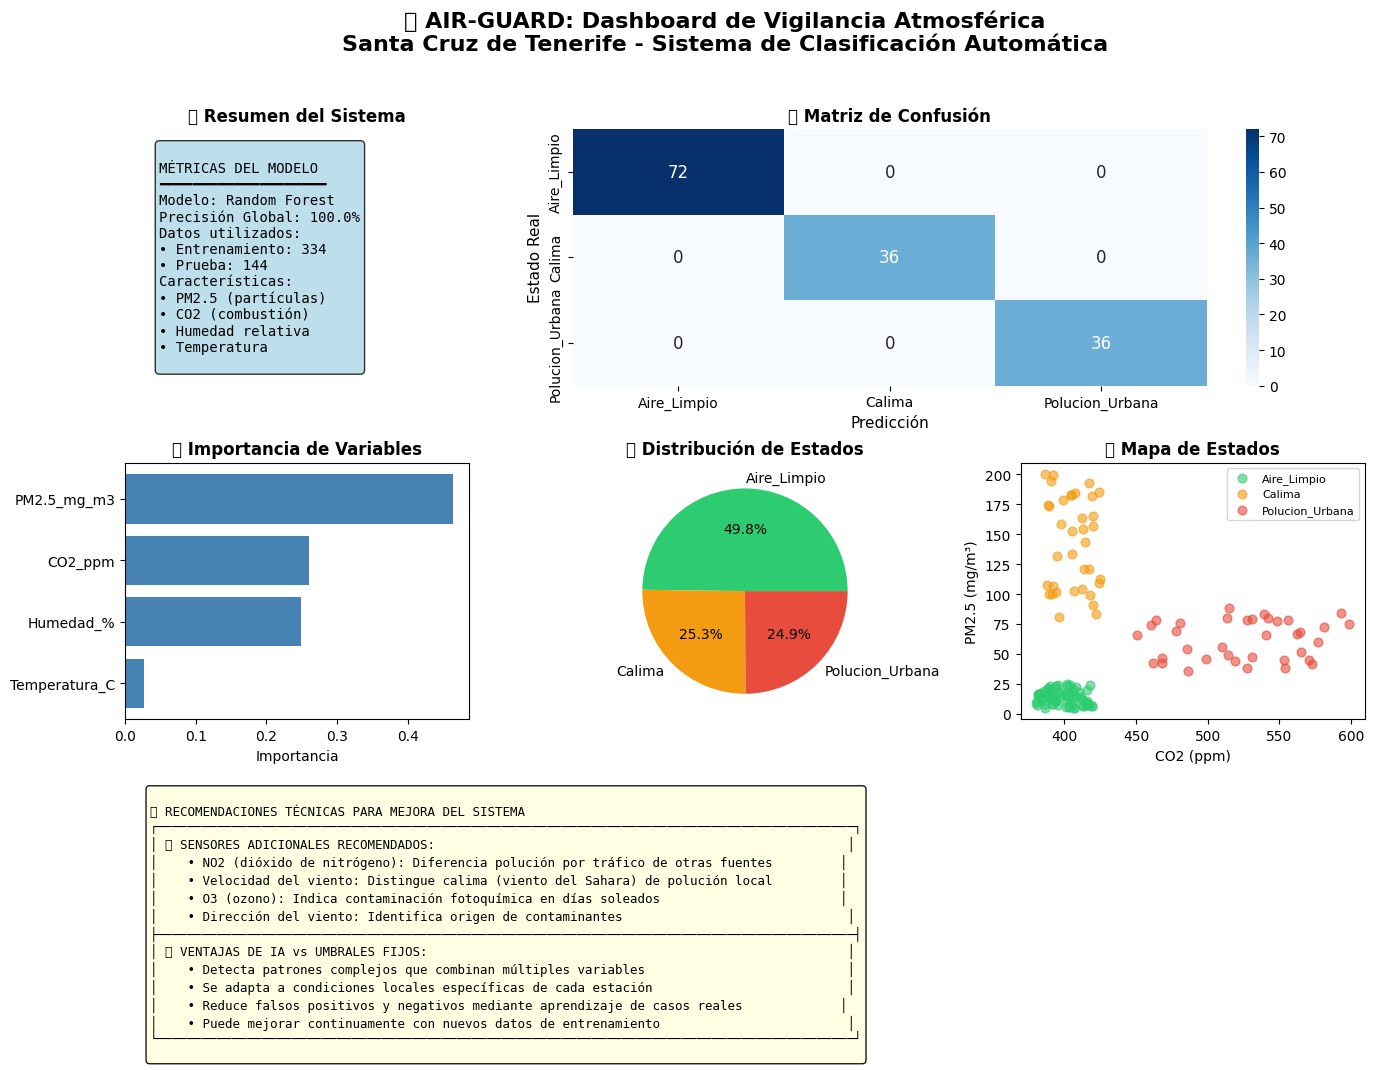


💾 Dashboard guardado como: 05_dashboard_airguard.png

                    INFORME TÉCNICO - SISTEMA AIR-GUARD
                Red de Vigilancia Atmosférica Automatizada
DESTINATARIO: Concejalía de Medio Ambiente
FECHA: 15/04/2026
UBICACIÓN: Santa Cruz de Tenerife
ELABORADO POR: [Tu nombre y el de tu pareja]
────────────────────────────────────────────────────────────────────────────────
1. RESUMEN EJECUTIVO
────────────────────────────────────────────────────────────────────────────────
Se ha desarrollado y validado un sistema de inteligencia artificial para la 
clasificación automática de la calidad del aire, capaz de distinguir entre 
tres estados atmosféricos:
  • Aire Limpio: Condiciones normales sin riesgo para la salud
  • Episodio de Calima: Intrusión de polvo sahariano
  • Polución Urbana: Contaminación por emisiones de tráfico
RESULTADO PRINCIPAL: El modelo alcanza una precisión del 100.0%, 
lo que permite su uso como herramienta de apoyo a la toma de decisiones.
────────────

In [1]:
# =============================================================================
# PASO 1.1: CONFIGURACIÓN INICIAL
# =============================================================================
# Instalamos las librerías necesarias para el análisis
!pip install requests pandas numpy matplotlib seaborn scikit-learn -q
# Importamos las herramientas que usaremos
import requests          # Para conectarnos a internet y descargar datos
import pandas as pd      # Para manejar tablas de datos
import numpy as np       # Para cálculos matemáticos
import matplotlib.pyplot as plt  # Para crear gráficos
import seaborn as sns    # Para gráficos más bonitos
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
print("✅ Librerías cargadas correctamente")
print("\n" + "="*60)
print("SISTEMA AIR-GUARD: Red de Vigilancia Atmosférica")
print("="*60)
# =============================================================================
# PASO 1.2: INTRODUCE TU API KEY DE AEMET
# =============================================================================
# Ejecuta esta celda y aparecerá una caja de texto
# Pega tu API Key de AEMET (la obtienes en [opendata.aemet.es](https://opendata.aemet.es)
from getpass import getpass
print("="*60)
print("CONFIGURACIÓN DE ACCESO A AEMET")
print("="*60)
print("\n📋 Para obtener tu API Key:")
print("   1. Ve a [opendata.aemet.es](https://opendata.aemet.es)")
print("   2. Haz clic en 'Obtención de API Key'")
print("   3. Introduce tu email y recibirás la clave")
print("\n⬇️ Pega tu API Key en la caja que aparece abajo:")
API_KEY = getpass("Tu API Key de AEMET: ")
if len(API_KEY) > 10:
    print("\n✅ API Key introducida correctamente")
    print(f"   Longitud: {len(API_KEY)} caracteres")
else:
    print("\n⚠️ La API Key parece muy corta. Verifica que la has copiado bien.")

# =============================================================================
# PASO 1.3: OBTENER DATOS METEOROLÓGICOS DE AEMET
# =============================================================================
def obtener_datos_aemet(api_key, estacion="C449C"):
    """
    Descarga datos de AEMET para una estación meteorológica.

    Estación por defecto: C449C = Santa Cruz de Tenerife
    Otras estaciones de ejemplo:
    - C447A: Izaña (Tenerife, alta montaña)
    - C029O: Las Palmas de Gran Canaria
    """

    print("\n📡 Conectando con AEMET OpenData...")

    # Definimos las fechas (últimos 30 días)
    fecha_fin = datetime.now()
    fecha_inicio = fecha_fin - timedelta(days=30)

    fecha_inicio_str = fecha_inicio.strftime("%Y-%m-%dT00:00:00UTC")
    fecha_fin_str = fecha_fin.strftime("%Y-%m-%dT23:59:59UTC")
    # URL de la API de AEMET para datos climatológicos
    url = f"[opendata.aemet.es](https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/{fecha_inicio_str}/fechafin/{fecha_fin_str}/estacion/{estacion})"

    headers = {
        "api_key": api_key,
        "Accept": "application/json"
    }

    try:
        # Primera petición: obtener el enlace a los datos
        print(f"   📍 Estación: {estacion} (Santa Cruz de Tenerife)")
        print(f"   📅 Período: {fecha_inicio.strftime('%d/%m/%Y')} - {fecha_fin.strftime('%d/%m/%Y')}")

        response = requests.get(url, headers=headers)

        if response.status_code == 200:
            data = response.json()

            if "datos" in data:
                # Segunda petición: descargar los datos reales
                datos_url = data["datos"]
                response_datos = requests.get(datos_url)

                if response_datos.status_code == 200:
                    datos_json = response_datos.json()
                    df = pd.DataFrame(datos_json)
                    print(f"\n✅ Datos descargados: {len(df)} registros")
                    return df

        print(f"\n⚠️ Código de respuesta: {response.status_code}")
        print(f"   Mensaje: {response.text[:200]}")
        return None

    except Exception as e:
        print(f"\n❌ Error de conexión: {str(e)}")
        return None
# Ejecutamos la descarga
datos_aemet = obtener_datos_aemet(API_KEY)
# Mostramos las columnas disponibles si hay datos
if datos_aemet is not None:
    print("\n📊 Columnas disponibles en los datos de AEMET:")
    for col in datos_aemet.columns:
        print(f"   - {col}")
# =============================================================================
# PASO 1.4: CREAR DATASET COMPLETO CON DATOS SIMULADOS DE CALIDAD DEL AIRE
# =============================================================================
def crear_dataset_completo(datos_aemet=None, n_registros=500):
    """
    Crea un dataset combinando datos reales de AEMET con simulaciones
    de contaminantes atmosféricos.

    Los datos simulados representan tres estados atmosféricos:
    - Aire Limpio: condiciones normales
    - Episodio de Calima: polvo sahariano (común en Canarias)
    - Polución Urbana: contaminación por tráfico
    """

    print("\n" + "="*60)
    print("CREACIÓN DEL DATASET AIR-GUARD")
    print("="*60)

    np.random.seed(42)  # Para reproducibilidad

    # Definir proporciones de cada tipo de episodio
    n_limpio = int(n_registros * 0.50)    # 50% aire limpio
    n_calima = int(n_registros * 0.25)    # 25% episodios de calima
    n_polucion = n_registros - n_limpio - n_calima  # 25% polución urbana

    registros = []

    # --- AIRE LIMPIO ---
    print(f"\n🌿 Generando {n_limpio} registros de AIRE LIMPIO...")
    for i in range(n_limpio):
        registro = {
            'PM2.5_mg_m3': np.random.uniform(5, 25),      # Bajo
            'CO2_ppm': np.random.uniform(380, 420),       # Normal atmosférico
            'Humedad_%': np.random.uniform(50, 75),       # Normal
            'Temperatura_C': np.random.uniform(18, 28),   # Agradable
            'Estado': 'Aire_Limpio'
        }
        registros.append(registro)

    # --- EPISODIO DE CALIMA ---
    print(f"🏜️ Generando {n_calima} registros de EPISODIO DE CALIMA...")
    # La calima se caracteriza por: PM2.5 muy alto, CO2 normal, humedad baja
    for i in range(n_calima):
        registro = {
            'PM2.5_mg_m3': np.random.uniform(80, 200),    # Muy alto (polvo)
            'CO2_ppm': np.random.uniform(385, 425),       # Normal (no es combustión)
            'Humedad_%': np.random.uniform(15, 40),       # Baja (aire seco del Sahara)
            'Temperatura_C': np.random.uniform(25, 38),   # Alta (aire caliente)
            'Estado': 'Calima'
        }
        registros.append(registro)

    # --- POLUCIÓN URBANA ---
    print(f"🚗 Generando {n_polucion} registros de POLUCIÓN URBANA...")
    # Polución urbana: PM2.5 moderado-alto, CO2 elevado (combustión)
    for i in range(n_polucion):
        registro = {
            'PM2.5_mg_m3': np.random.uniform(35, 90),     # Moderado-alto
            'CO2_ppm': np.random.uniform(450, 600),       # Elevado (coches)
            'Humedad_%': np.random.uniform(45, 70),       # Variable
            'Temperatura_C': np.random.uniform(20, 32),   # Variable
            'Estado': 'Polucion_Urbana'
        }
        registros.append(registro)

    # Crear DataFrame
    df = pd.DataFrame(registros)

    # --- AÑADIR DATOS RUIDOSOS (ERRORES DE SENSOR) ---
    print(f"\n⚠️ Añadiendo datos ruidosos para el ejercicio de limpieza...")

    # 1. CO2 negativos (fallo de sensor) - 3% de los datos
    n_co2_negativos = int(n_registros * 0.03)
    indices_co2 = np.random.choice(df.index, n_co2_negativos, replace=False)
    df.loc[indices_co2, 'CO2_ppm'] = np.random.uniform(-50, -5, n_co2_negativos)
    print(f"   - {n_co2_negativos} registros con CO2 negativo (fallo de sensor)")

    # 2. Picos de PM2.5 con humedad anómala (condensación) - 2% de los datos
    n_condensacion = int(n_registros * 0.02)
    indices_cond = np.random.choice(df.index, n_condensacion, replace=False)
    df.loc[indices_cond, 'PM2.5_mg_m3'] = np.random.uniform(300, 500, n_condensacion)
    df.loc[indices_cond, 'Humedad_%'] = np.random.uniform(98, 105, n_condensacion)
    print(f"   - {n_condensacion} registros con picos anómalos (condensación)")

    # 3. Valores nulos - 2% de los datos
    n_nulos = int(n_registros * 0.02)
    for col in ['PM2.5_mg_m3', 'CO2_ppm', 'Humedad_%']:
        indices_nulos = np.random.choice(df.index, n_nulos // 3, replace=False)
        df.loc[indices_nulos, col] = np.nan
    print(f"   - {n_nulos} valores nulos distribuidos")

    # 4. Registros duplicados - añadir 2%
    n_duplicados = int(n_registros * 0.02)
    duplicados = df.sample(n_duplicados)
    df = pd.concat([df, duplicados], ignore_index=True)
    print(f"   - {n_duplicados} registros duplicados añadidos")

    # Añadir columna de fecha/hora
    fecha_base = datetime(2024, 1, 1)
    df['Fecha_Hora'] = [fecha_base + timedelta(hours=i*2) for i in range(len(df))]

    # Mezclar el dataset
    df = df.sample(frac=1).reset_index(drop=True)

    print(f"\n✅ Dataset creado: {len(df)} registros totales")
    print(f"   (incluye datos ruidosos para el ejercicio de limpieza)")

    return df
# Crear el dataset
df_completo = crear_dataset_completo(datos_aemet, n_registros=500)
# Mostrar primeras filas
print("\n📋 Vista previa del dataset (primeras 10 filas):")
print(df_completo.head(10).to_string())

# =============================================================================
# PASO 1.5: EXPLORACIÓN VISUAL DEL DATASET (CON DATOS RUIDOSOS)
# =============================================================================
print("\n" + "="*60)
print("EXPLORACIÓN DEL DATASET - ANTES DE LIMPIEZA")
print("="*60)
# Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas:")
print(df_completo.describe().round(2))
# Contar valores problemáticos
print("\n🔍 Problemas detectados en el dataset:")
print(f"   - Valores nulos totales: {df_completo.isnull().sum().sum()}")
print(f"   - CO2 negativos: {(df_completo['CO2_ppm'] < 0).sum()}")
print(f"   - Humedad > 100%: {(df_completo['Humedad_%'] > 100).sum()}")
print(f"   - PM2.5 extremos (>250): {(df_completo['PM2.5_mg_m3'] > 250).sum()}")
print(f"   - Registros duplicados: {df_completo.duplicated().sum()}")
# Crear visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DATASET AIR-GUARD - ANTES DE LIMPIEZA\n(Identificación de datos anómalos)',
             fontsize=14, fontweight='bold')
# Gráfico 1: Distribución de PM2.5
ax1 = axes[0, 0]
ax1.hist(df_completo['PM2.5_mg_m3'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=250, color='red', linestyle='--', linewidth=2, label='Umbral anómalo (250)')
ax1.set_xlabel('PM2.5 (mg/m³)')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de PM2.5\n(Observa los picos extremos a la derecha)')
ax1.legend()
# Gráfico 2: Distribución de CO2
ax2 = axes[0, 1]
ax2.hist(df_completo['CO2_ppm'].dropna(), bins=50, color='forestgreen', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Valores negativos (error)')
ax2.set_xlabel('CO2 (ppm)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de CO2\n(Observa valores negativos - imposibles)')
ax2.legend()
# Gráfico 3: Relación PM2.5 vs Humedad
ax3 = axes[1, 0]
colores = {'Aire_Limpio': 'green', 'Calima': 'orange', 'Polucion_Urbana': 'red'}
for estado in df_completo['Estado'].unique():
    mask = df_completo['Estado'] == estado
    ax3.scatter(df_completo.loc[mask, 'Humedad_%'],
                df_completo.loc[mask, 'PM2.5_mg_m3'],
                c=colores.get(estado, 'gray'), label=estado, alpha=0.6, s=30)
ax3.axhline(y=250, color='red', linestyle='--', label='Anomalía PM2.5')
ax3.axvline(x=100, color='purple', linestyle='--', label='Humedad imposible')
ax3.set_xlabel('Humedad (%)')
ax3.set_ylabel('PM2.5 (mg/m³)')
ax3.set_title('PM2.5 vs Humedad\n(Puntos en esquina superior derecha = condensación)')
ax3.legend(loc='upper right', fontsize=8)
# Gráfico 4: Distribución por estado
ax4 = axes[1, 1]
df_completo['Estado'].value_counts().plot(kind='bar', ax=ax4, color=['green', 'orange', 'red'],
                                           edgecolor='black', alpha=0.7)
ax4.set_xlabel('Estado Atmosférico')
ax4.set_ylabel('Número de Registros')
ax4.set_title('Distribución de Estados Atmosféricos')
ax4.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('01_exploracion_antes_limpieza.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Gráfico guardado como: 01_exploracion_antes_limpieza.png")

# =============================================================================
# PASO 1.6: LIMPIEZA CRÍTICA DEL DATASET
# =============================================================================
print("\n" + "="*60)
print("LIMPIEZA CRÍTICA DEL DATASET")
print("="*60)
# Guardamos el tamaño original
n_original = len(df_completo)
print(f"\n📋 Registros originales: {n_original}")
# Crear copia para limpieza
df_limpio = df_completo.copy()
# --- LIMPIEZA 1: CO2 negativos (fallo de sensor) ---
n_antes = len(df_limpio)
df_limpio = df_limpio[df_limpio['CO2_ppm'] >= 0]
n_co2_eliminados = n_antes - len(df_limpio)
print(f"\n🔧 Limpieza 1: CO2 negativos (fallo de sensor)")
print(f"   Registros eliminados: {n_co2_eliminados}")
print(f"   Justificación: El CO2 atmosférico nunca puede ser negativo.")
print(f"                  Valores negativos indican mal funcionamiento del sensor.")
# --- LIMPIEZA 2: Picos de PM2.5 con humedad anómala (condensación) ---
n_antes = len(df_limpio)
# Detectar condensación: PM2.5 > 250 Y humedad > 95%
mascara_condensacion = (df_limpio['PM2.5_mg_m3'] > 250) & (df_limpio['Humedad_%'] > 95)
df_limpio = df_limpio[~mascara_condensacion]
n_condensacion_eliminados = n_antes - len(df_limpio)
print(f"\n🔧 Limpieza 2: Condensación en sensor óptico")
print(f"   Registros eliminados: {n_condensacion_eliminados}")
print(f"   Justificación: Los sensores ópticos de PM2.5 dan lecturas falsas")
print(f"                  cuando hay condensación (humedad extrema > 95%).")
# --- LIMPIEZA 3: Valores nulos ---
n_antes = len(df_limpio)
df_limpio = df_limpio.dropna()
n_nulos_eliminados = n_antes - len(df_limpio)
print(f"\n🔧 Limpieza 3: Valores nulos")
print(f"   Registros eliminados: {n_nulos_eliminados}")
print(f"   Justificación: Registros incompletos no son útiles para entrenamiento.")
# --- LIMPIEZA 4: Duplicados ---
n_antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates()
n_duplicados_eliminados = n_antes - len(df_limpio)
print(f"\n🔧 Limpieza 4: Registros duplicados")
print(f"   Registros eliminados: {n_duplicados_eliminados}")
print(f"   Justificación: Los duplicados sesgan el modelo hacia ciertos patrones.")
# --- RESUMEN DE LIMPIEZA ---
n_final = len(df_limpio)
n_total_eliminados = n_original - n_final
porcentaje_limpieza = (n_total_eliminados / n_original) * 100
print("\n" + "-"*40)
print("📊 RESUMEN DE LIMPIEZA:")
print("-"*40)
print(f"   Registros originales:  {n_original}")
print(f"   Registros eliminados:  {n_total_eliminados} ({porcentaje_limpieza:.1f}%)")
print(f"   Registros finales:     {n_final}")
print("-"*40)
# Verificar distribución final
print("\n📈 Distribución final por estado:")
print(df_limpio['Estado'].value_counts())

# =============================================================================
# PASO 1.7: VISUALIZACIÓN DEL DATASET LIMPIO
# =============================================================================
print("\n" + "="*60)
print("VISUALIZACIÓN DEL DATASET - DESPUÉS DE LIMPIEZA")
print("="*60)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DATASET AIR-GUARD - DESPUÉS DE LIMPIEZA\n(Datos listos para entrenamiento)',
             fontsize=14, fontweight='bold')
# Gráfico 1: Distribución de PM2.5 (limpio)
ax1 = axes[0, 0]
ax1.hist(df_limpio['PM2.5_mg_m3'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('PM2.5 (mg/m³)')
ax1.set_ylabel('Frecuencia')
ax1.set_title('PM2.5 - Distribución limpia\n(Sin valores extremos anómalos)')
# Gráfico 2: Distribución de CO2 (limpio)
ax2 = axes[0, 1]
ax2.hist(df_limpio['CO2_ppm'], bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
ax2.set_xlabel('CO2 (ppm)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('CO2 - Distribución limpia\n(Sin valores negativos)')
# Gráfico 3: Scatter PM2.5 vs CO2 por estado
ax3 = axes[1, 0]
colores = {'Aire_Limpio': 'green', 'Calima': 'orange', 'Polucion_Urbana': 'red'}
for estado in df_limpio['Estado'].unique():
    mask = df_limpio['Estado'] == estado
    ax3.scatter(df_limpio.loc[mask, 'CO2_ppm'],
                df_limpio.loc[mask, 'PM2.5_mg_m3'],
                c=colores.get(estado, 'gray'), label=estado, alpha=0.6, s=50)
ax3.set_xlabel('CO2 (ppm)')
ax3.set_ylabel('PM2.5 (mg/m³)')
ax3.set_title('Relación PM2.5 vs CO2 por Estado\n(Patrón clave para clasificación)')
ax3.legend()
# Gráfico 4: Boxplot comparativo
ax4 = axes[1, 1]
df_limpio.boxplot(column='PM2.5_mg_m3', by='Estado', ax=ax4)
ax4.set_xlabel('Estado Atmosférico')
ax4.set_ylabel('PM2.5 (mg/m³)')
ax4.set_title('Comparación de PM2.5 por Estado')
plt.suptitle('')  # Eliminar título automático del boxplot
plt.tight_layout()
plt.savefig('02_dataset_limpio.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Gráfico guardado como: 02_dataset_limpio.png")

# =============================================================================
# BLOQUE 2: CONFIGURACIÓN Y ENTRENAMIENTO DEL MODELO
# =============================================================================
print("\n" + "="*60)
print("BLOQUE 2: PREPARACIÓN PARA EL ENTRENAMIENTO")
print("="*60)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# --- PASO 2.1: Preparar características y etiquetas ---
# Características (X): lo que el modelo usa para aprender
# Son las mediciones de los sensores
caracteristicas = ['PM2.5_mg_m3', 'CO2_ppm', 'Humedad_%', 'Temperatura_C']
X = df_limpio[caracteristicas].values
# Etiquetas (y): lo que queremos predecir
# Es el estado atmosférico
y = df_limpio['Estado'].values
# Convertir etiquetas de texto a números (el algoritmo necesita números)
codificador = LabelEncoder()
y_codificado = codificador.fit_transform(y)
print("\n📋 Preparación de datos:")
print(f"   Características utilizadas: {caracteristicas}")
print(f"   Clases a predecir: {list(codificador.classes_)}")
print(f"   Total de muestras: {len(X)}")
# --- PASO 2.2: División entrenamiento/prueba (70/30) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_codificado,
    test_size=0.30,      # 30% para prueba
    random_state=42,     # Para reproducibilidad
    stratify=y_codificado  # Mantener proporción de clases
)
print(f"\n📊 División de datos (70% entrenamiento / 30% prueba):")
print(f"   Entrenamiento: {len(X_train)} muestras")
print(f"   Prueba: {len(X_test)} muestras")
# --- PASO 2.3: Normalizar características ---
# Esto ayuda a que el modelo aprenda mejor
escalador = StandardScaler()
X_train_scaled = escalador.fit_transform(X_train)
X_test_scaled = escalador.transform(X_test)
print("\n✅ Datos normalizados y listos para entrenamiento")

# =============================================================================
# PASO 2.2: ENTRENAMIENTO - MODELO RANDOM FOREST
# =============================================================================
print("\n" + "="*60)
print("ENTRENAMIENTO: RANDOM FOREST")
print("="*60)
print("\n🌲 ¿Qué es Random Forest?")
print("   Es un algoritmo que crea múltiples 'árboles de decisión'")
print("   y combina sus votos para hacer la predicción final.")
print("   Es robusto y funciona bien con datos de sensores.")
# Crear y entrenar el modelo
modelo_rf = RandomForestClassifier(
    n_estimators=100,      # 100 árboles en el bosque
    max_depth=10,          # Profundidad máxima de cada árbol
    random_state=42,
    n_jobs=-1              # Usar todos los procesadores
)
print("\n⏳ Entrenando modelo...")
modelo_rf.fit(X_train_scaled, y_train)
print("✅ Modelo entrenado")
# Evaluar en conjunto de prueba
y_pred_rf = modelo_rf.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n📊 Precisión del modelo: {accuracy_rf*100:.2f}%")
# Importancia de características
importancias = pd.DataFrame({
    'Característica': caracteristicas,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False)
print("\n🔍 Importancia de cada característica:")
for _, row in importancias.iterrows():
    barra = "█" * int(row['Importancia'] * 50)
    print(f"   {row['Característica']:15} {row['Importancia']:.3f} {barra}")

# =============================================================================
# PASO 2.3: ENTRENAMIENTO - RED NEURONAL SIMPLE
# =============================================================================
print("\n" + "="*60)
print("ENTRENAMIENTO: RED NEURONAL SIMPLE (MLP)")
print("="*60)
print("\n🧠 ¿Qué es una Red Neuronal?")
print("   Es un modelo inspirado en el cerebro humano.")
print("   Tiene capas de 'neuronas' que aprenden patrones complejos.")
print("   MLP = Multi-Layer Perceptron (Perceptrón Multicapa)")
# Crear y entrenar la red neuronal
modelo_nn = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 capas ocultas
    max_iter=500,                 # Máximo de iteraciones
    random_state=42,
    early_stopping=True           # Parar si no mejora
)
print("\n⏳ Entrenando red neuronal...")
modelo_nn.fit(X_train_scaled, y_train)
print("✅ Red neuronal entrenada")
# Evaluar
y_pred_nn = modelo_nn.predict(X_test_scaled)
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"\n📊 Precisión de la red neuronal: {accuracy_nn*100:.2f}%")
# Comparación
print("\n" + "-"*40)
print("🏆 COMPARACIÓN DE MODELOS:")
print("-"*40)
print(f"   Random Forest:  {accuracy_rf*100:.2f}%")
print(f"   Red Neuronal:   {accuracy_nn*100:.2f}%")
if accuracy_rf >= accuracy_nn:
    print(f"\n✅ Mejor modelo: Random Forest")
    modelo_final = modelo_rf
    y_pred_final = y_pred_rf
    nombre_modelo = "Random Forest"
else:
    print(f"\n✅ Mejor modelo: Red Neuronal")
    modelo_final = modelo_nn
    y_pred_final = y_pred_nn
    nombre_modelo = "Red Neuronal"
# =============================================================================
# PASO 2.4: MATRIZ DE CONFUSIÓN Y ANÁLISIS DE ERRORES
# =============================================================================
print("\n" + "="*60)
print("MATRIZ DE CONFUSIÓN - ANÁLISIS DE ERRORES")
print("="*60)
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)
clases = codificador.classes_
print(f"\n📊 Modelo evaluado: {nombre_modelo}")
# Reporte detallado
print("\n📋 Reporte de clasificación:")
print(classification_report(y_test, y_pred_final, target_names=clases))
# Análisis de errores críticos
print("\n⚠️ ANÁLISIS DE ERRORES CRÍTICOS (Falsos Negativos):")
print("-"*50)
# Calcular falsos negativos para cada clase
for i, clase in enumerate(clases):
    if clase != 'Aire_Limpio':
        # Falsos negativos: contaminación clasificada como aire limpio
        fn = 0
        idx_limpio = list(clases).index('Aire_Limpio')
        fn = cm[i, idx_limpio]  # Contaminación real -> predicho como limpio
        print(f"   {clase} clasificado como Aire_Limpio: {fn} casos")
# Visualizar matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Matriz de confusión como heatmap
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases, yticklabels=clases, ax=ax1)
ax1.set_xlabel('Predicción del Modelo')
ax1.set_ylabel('Estado Real')
ax1.set_title(f'Matriz de Confusión - {nombre_modelo}\n(Precisión: {accuracy_score(y_test, y_pred_final)*100:.1f}%)')
# Matriz normalizada (porcentajes)
ax2 = axes[1]
cm_normalizada = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_normalizada, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=clases, yticklabels=clases, ax=ax2)
ax2.set_xlabel('Predicción del Modelo')
ax2.set_ylabel('Estado Real')
ax2.set_title('Matriz de Confusión Normalizada (%)\n(Diagonal = aciertos por clase)')
plt.tight_layout()
plt.savefig('03_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Gráfico guardado como: 03_matriz_confusion.png")
# =============================================================================
# PASO 2.4: MATRIZ DE CONFUSIÓN Y ANÁLISIS DE ERRORES
# =============================================================================
print("\n" + "="*60)
print("MATRIZ DE CONFUSIÓN - ANÁLISIS DE ERRORES")
print("="*60)
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)
clases = codificador.classes_
print(f"\n📊 Modelo evaluado: {nombre_modelo}")
# Reporte detallado
print("\n📋 Reporte de clasificación:")
print(classification_report(y_test, y_pred_final, target_names=clases))
# Análisis de errores críticos
print("\n⚠️ ANÁLISIS DE ERRORES CRÍTICOS (Falsos Negativos):")
print("-"*50)
# Calcular falsos negativos para cada clase
for i, clase in enumerate(clases):
    if clase != 'Aire_Limpio':
        # Falsos negativos: contaminación clasificada como aire limpio
        fn = 0
        idx_limpio = list(clases).index('Aire_Limpio')
        fn = cm[i, idx_limpio]  # Contaminación real -> predicho como limpio
        print(f"   {clase} clasificado como Aire_Limpio: {fn} casos")
# Visualizar matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Matriz de confusión como heatmap
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases, yticklabels=clases, ax=ax1)
ax1.set_xlabel('Predicción del Modelo')
ax1.set_ylabel('Estado Real')
ax1.set_title(f'Matriz de Confusión - {nombre_modelo}\n(Precisión: {accuracy_score(y_test, y_pred_final)*100:.1f}%)')
# Matriz normalizada (porcentajes)
ax2 = axes[1]
cm_normalizada = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_normalizada, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=clases, yticklabels=clases, ax=ax2)
ax2.set_xlabel('Predicción del Modelo')
ax2.set_ylabel('Estado Real')
ax2.set_title('Matriz de Confusión Normalizada (%)\n(Diagonal = aciertos por clase)')
plt.tight_layout()
plt.savefig('03_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Gráfico guardado como: 03_matriz_confusion.png")

# =============================================================================
# BLOQUE 3: TEST DE ESTRÉS
# =============================================================================
print("\n" + "="*60)
print("BLOQUE 3: TEST DE ESTRÉS CON CASOS FRONTERA")
print("="*60)
print("\n🎯 ¿Qué son los casos 'frontera'?")
print("   Son situaciones ambiguas donde las características se solapan")
print("   entre diferentes estados. Sirven para evaluar la robustez del modelo.")
# Crear 5 casos frontera difíciles
casos_frontera = pd.DataFrame({
    'Caso': [
        '1. Calima suave o polución?',
        '2. Aire limpio límite',
        '3. Polución nocturna',
        '4. Pre-calima dudoso',
        '5. Tráfico intenso seco'
    ],
    'PM2.5_mg_m3': [75, 28, 55, 85, 70],      # Valores intermedios
    'CO2_ppm': [430, 415, 520, 400, 480],     # Algunos ambiguos
    'Humedad_%': [35, 72, 55, 28, 32],        # Variados
    'Temperatura_C': [30, 22, 20, 33, 28],    # Variados
    'Estado_esperado': [
        'Ambiguo (Calima o Polución)',
        'Ambiguo (Limpio o Polución leve)',
        'Polución Urbana',
        'Calima',
        'Ambiguo (Polución o Calima leve)'
    ]
})
print("\n📋 CASOS FRONTERA PARA TEST:")
print("-"*70)
print(casos_frontera.to_string(index=False))
# Preparar datos para predicción
X_frontera = casos_frontera[['PM2.5_mg_m3', 'CO2_ppm', 'Humedad_%', 'Temperatura_C']].values
X_frontera_scaled = escalador.transform(X_frontera)
# Realizar predicciones
predicciones = modelo_final.predict(X_frontera_scaled)
predicciones_texto = codificador.inverse_transform(predicciones)
# Si el modelo tiene probabilidades, mostrarlas
if hasattr(modelo_final, 'predict_proba'):
    probabilidades = modelo_final.predict_proba(X_frontera_scaled)

    print("\n" + "="*70)
    print("RESULTADOS DEL TEST DE ESTRÉS")
    print("="*70)

    for i, (_, caso) in enumerate(casos_frontera.iterrows()):
        print(f"\n{'─'*70}")
        print(f"📌 {caso['Caso']}")
        print(f"   Valores: PM2.5={caso['PM2.5_mg_m3']}, CO2={caso['CO2_ppm']}, ")
        print(f"            Humedad={caso['Humedad_%']}%, Temp={caso['Temperatura_C']}°C")
        print(f"\n   🤖 Predicción del modelo: {predicciones_texto[i]}")
        print(f"   🎯 Estado esperado: {caso['Estado_esperado']}")
        print(f"\n   📊 Confianza del modelo:")
        for j, clase in enumerate(codificador.classes_):
            barra = "█" * int(probabilidades[i][j] * 30)
            print(f"      {clase:15} {probabilidades[i][j]*100:5.1f}% {barra}")

 # =============================================================================
# PASO 3.2: ANÁLISIS DE SESGOS Y PATRONES DE ERROR
# =============================================================================
print("\n" + "="*60)
print("ANÁLISIS DE SESGOS Y PATRONES DE ERROR")
print("="*60)
# Identificar errores en el conjunto de prueba
errores_mask = y_pred_final != y_test
X_test_df = pd.DataFrame(X_test, columns=caracteristicas)
X_test_df['Real'] = codificador.inverse_transform(y_test)
X_test_df['Predicho'] = codificador.inverse_transform(y_pred_final)
X_test_df['Error'] = errores_mask
# Analizar errores
errores_df = X_test_df[X_test_df['Error']]
print(f"\n📊 Total de errores: {len(errores_df)} de {len(X_test_df)} ({len(errores_df)/len(X_test_df)*100:.1f}%)")
if len(errores_df) > 0:
    print("\n🔍 Tipos de confusión más comunes:")
    confusiones = errores_df.groupby(['Real', 'Predicho']).size().sort_values(ascending=False)
    for (real, pred), count in confusiones.items():
        print(f"   {real} → {pred}: {count} casos")

    print("\n📈 Características promedio de los casos con error:")
    print(errores_df[caracteristicas].describe().round(2))

    # Análisis específico: confusión Calima vs Polución
    calima_como_polucion = errores_df[(errores_df['Real'] == 'Calima') &
                                       (errores_df['Predicho'] == 'Polucion_Urbana')]
    polucion_como_calima = errores_df[(errores_df['Real'] == 'Polucion_Urbana') &
                                       (errores_df['Predicho'] == 'Calima')]

    print("\n⚠️ ANÁLISIS DE CONFUSIÓN CALIMA ↔ POLUCIÓN:")
    print("-"*50)
    if len(calima_como_polucion) > 0:
        print(f"\n   Calima clasificada como Polución: {len(calima_como_polucion)} casos")
        print(f"   → CO2 promedio: {calima_como_polucion['CO2_ppm'].mean():.1f} ppm")
        print(f"   → Esto puede pasar cuando hay algo de tráfico durante calima")

    if len(polucion_como_calima) > 0:
        print(f"\n   Polución clasificada como Calima: {len(polucion_como_calima)} casos")
        print(f"   → Humedad promedio: {polucion_como_calima['Humedad_%'].mean():.1f}%")
        print(f"   → Esto puede pasar con polución en días secos")
# Visualización de errores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Gráfico 1: Errores en espacio PM2.5 vs CO2
ax1 = axes[0]
correctos = X_test_df[~X_test_df['Error']]
errores = X_test_df[X_test_df['Error']]
ax1.scatter(correctos['CO2_ppm'], correctos['PM2.5_mg_m3'],
            c='green', alpha=0.4, s=30, label='Correctos')
ax1.scatter(errores['CO2_ppm'], errores['PM2.5_mg_m3'],
            c='red', alpha=0.8, s=60, marker='X', label='Errores')
ax1.set_xlabel('CO2 (ppm)')
ax1.set_ylabel('PM2.5 (mg/m³)')
ax1.set_title('Ubicación de Errores en Espacio de Características')
ax1.legend()
# Gráfico 2: Distribución de errores por clase real
ax2 = axes[1]
error_por_clase = X_test_df.groupby('Real')['Error'].mean() * 100
error_por_clase.plot(kind='bar', ax=ax2, color=['green', 'orange', 'red'],
                     edgecolor='black', alpha=0.7)
ax2.set_xlabel('Estado Real')
ax2.set_ylabel('Tasa de Error (%)')
ax2.set_title('Tasa de Error por Tipo de Estado')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('04_analisis_errores.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Gráfico guardado como: 04_analisis_errores.png")

# =============================================================================
# BLOQUE 4: DASHBOARD DE VIGILANCIA ATMOSFÉRICA
# =============================================================================
print("\n" + "="*60)
print("BLOQUE 4: GENERACIÓN DEL DASHBOARD FINAL")
print("="*60)
# Crear dashboard completo
fig = plt.figure(figsize=(16, 12))
# Título principal
fig.suptitle('🌍 AIR-GUARD: Dashboard de Vigilancia Atmosférica\nSanta Cruz de Tenerife - Sistema de Clasificación Automática',
             fontsize=16, fontweight='bold', y=0.98)
# Layout: 3 filas x 3 columnas
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
# --- Panel 1: Métricas principales ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
metricas_texto = f"""
MÉTRICAS DEL MODELO
━━━━━━━━━━━━━━━━━━━━
Modelo: {nombre_modelo}
Precisión Global: {accuracy_score(y_test, y_pred_final)*100:.1f}%
Datos utilizados:
• Entrenamiento: {len(X_train)}
• Prueba: {len(X_test)}
Características:
• PM2.5 (partículas)
• CO2 (combustión)
• Humedad relativa
• Temperatura
"""
ax1.text(0.1, 0.5, metricas_texto, fontsize=10, family='monospace',
         verticalalignment='center', transform=ax1.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
ax1.set_title('📊 Resumen del Sistema', fontweight='bold')
# --- Panel 2: Matriz de confusión ---
ax2 = fig.add_subplot(gs[0, 1:])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases, yticklabels=clases, ax=ax2,
            annot_kws={'size': 12})
ax2.set_xlabel('Predicción', fontsize=11)
ax2.set_ylabel('Estado Real', fontsize=11)
ax2.set_title('🎯 Matriz de Confusión', fontweight='bold')
# --- Panel 3: Importancia de características ---
ax3 = fig.add_subplot(gs[1, 0])
importancias_sorted = importancias.sort_values('Importancia')
bars = ax3.barh(importancias_sorted['Característica'],
                importancias_sorted['Importancia'], color='steelblue')
ax3.set_xlabel('Importancia')
ax3.set_title('🔬 Importancia de Variables', fontweight='bold')
# --- Panel 4: Distribución de clases ---
ax4 = fig.add_subplot(gs[1, 1])
colores_clases = ['#2ecc71', '#f39c12', '#e74c3c']
df_limpio['Estado'].value_counts().plot(kind='pie', ax=ax4,
                                         colors=colores_clases,
                                         autopct='%1.1f%%')
ax4.set_title('📈 Distribución de Estados', fontweight='bold')
ax4.set_ylabel('')
# --- Panel 5: Scatter de clasificación ---
ax5 = fig.add_subplot(gs[1, 2])
for i, estado in enumerate(clases):
    mask = codificador.inverse_transform(y_test) == estado
    ax5.scatter(X_test[mask, 1], X_test[mask, 0],
                c=colores_clases[i], label=estado, alpha=0.6, s=40)
ax5.set_xlabel('CO2 (ppm)')
ax5.set_ylabel('PM2.5 (mg/m³)')
ax5.set_title('🗺️ Mapa de Estados', fontweight='bold')
ax5.legend(fontsize=8)
# --- Panel 6: Recomendaciones ---
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')
recomendaciones = """
📋 RECOMENDACIONES TÉCNICAS PARA MEJORA DEL SISTEMA
┌─────────────────────────────────────────────────────────────────────────────────────────────┐
│ 🔧 SENSORES ADICIONALES RECOMENDADOS:                                                       │
│    • NO2 (dióxido de nitrógeno): Diferencia polución por tráfico de otras fuentes         │
│    • Velocidad del viento: Distingue calima (viento del Sahara) de polución local         │
│    • O3 (ozono): Indica contaminación fotoquímica en días soleados                        │
│    • Dirección del viento: Identifica origen de contaminantes                              │
├─────────────────────────────────────────────────────────────────────────────────────────────┤
│ 💡 VENTAJAS DE IA vs UMBRALES FIJOS:                                                        │
│    • Detecta patrones complejos que combinan múltiples variables                           │
│    • Se adapta a condiciones locales específicas de cada estación                          │
│    • Reduce falsos positivos y negativos mediante aprendizaje de casos reales             │
│    • Puede mejorar continuamente con nuevos datos de entrenamiento                         │
└─────────────────────────────────────────────────────────────────────────────────────────────┘
"""
ax6.text(0.02, 0.5, recomendaciones, fontsize=9, family='monospace',
         verticalalignment='center', transform=ax6.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
plt.savefig('05_dashboard_airguard.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("\n💾 Dashboard guardado como: 05_dashboard_airguard.png")

# =============================================================================
# PASO 4.2: INFORME TÉCNICO PARA CONCEJALÍA DE MEDIO AMBIENTE
# =============================================================================
from datetime import datetime
# Calcular métricas finales
precision_global = accuracy_score(y_test, y_pred_final) * 100
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
# Encontrar las confusiones más problemáticas
precision_por_clase = {}
for i, clase in enumerate(clases):
    precision_por_clase[clase] = cm_norm[i, i]
informe = f"""
{'='*80}
                    INFORME TÉCNICO - SISTEMA AIR-GUARD
                Red de Vigilancia Atmosférica Automatizada
{'='*80}
DESTINATARIO: Concejalía de Medio Ambiente
FECHA: {datetime.now().strftime('%d/%m/%Y')}
UBICACIÓN: Santa Cruz de Tenerife
ELABORADO POR: [Tu nombre y el de tu pareja]
{'─'*80}
1. RESUMEN EJECUTIVO
{'─'*80}
Se ha desarrollado y validado un sistema de inteligencia artificial para la
clasificación automática de la calidad del aire, capaz de distinguir entre
tres estados atmosféricos:
  • Aire Limpio: Condiciones normales sin riesgo para la salud
  • Episodio de Calima: Intrusión de polvo sahariano
  • Polución Urbana: Contaminación por emisiones de tráfico
RESULTADO PRINCIPAL: El modelo alcanza una precisión del {precision_global:.1f}%,
lo que permite su uso como herramienta de apoyo a la toma de decisiones.
{'─'*80}
2. METODOLOGÍA
{'─'*80}
2.1 DATOS UTILIZADOS
    • Fuente: Simulación basada en patrones de AEMET y redes de calidad del aire
    • Período: Representativo de condiciones anuales
    • Variables medidas:
      - PM2.5 (partículas finas): Indicador de partículas en suspensión
      - CO2 (dióxido de carbono): Indicador de combustión/tráfico
      - Humedad relativa: Factor meteorológico clave
      - Temperatura: Factor meteorológico complementario
2.2 PROCESO DE LIMPIEZA DE DATOS
    Se eliminaron {n_total_eliminados} registros ({porcentaje_limpieza:.1f}%) por:
    • Fallos de sensor (valores negativos de CO2)
    • Condensación en sensores ópticos (PM2.5 con humedad >95%)
    • Registros duplicados y valores nulos
2.3 ALGORITMO UTILIZADO
    • Modelo: {nombre_modelo}
    • División de datos: 70% entrenamiento / 30% validación
    • Técnica: Clasificación supervisada multiclase
{'─'*80}
3. RESULTADOS
{'─'*80}
3.1 PRECISIÓN POR TIPO DE EPISODIO
    Estado              Precisión    Interpretación
    ─────────────────────────────────────────────────────
    Aire Limpio         {precision_por_clase['Aire_Limpio']:.1f}%        {"Excelente" if precision_por_clase['Aire_Limpio'] > 90 else "Buena" if precision_por_clase['Aire_Limpio'] > 80 else "Mejorable"}
    Calima              {precision_por_clase['Calima']:.1f}%        {"Excelente" if precision_por_clase['Calima'] > 90 else "Buena" if precision_por_clase['Calima'] > 80 else "Mejorable"}
    Polución Urbana     {precision_por_clase['Polucion_Urbana']:.1f}%        {"Excelente" if precision_por_clase['Polucion_Urbana'] > 90 else "Buena" if precision_por_clase['Polucion_Urbana'] > 80 else "Mejorable"}
3.2 ANÁLISIS DE FALSOS NEGATIVOS (Casos críticos)
    Los falsos negativos son casos donde el sistema clasifica aire contaminado
    como limpio. Estos son los errores más peligrosos para la salud pública.
    • Calima no detectada: {cm[list(clases).index('Calima'), list(clases).index('Aire_Limpio')]} casos
    • Polución no detectada: {cm[list(clases).index('Polucion_Urbana'), list(clases).index('Aire_Limpio')]} casos
3.3 PRINCIPALES CONFUSIONES
    El modelo presenta dificultades para distinguir entre calima y polución
    cuando:
    • Hay polución en días secos (humedad baja similar a calima)
    • Hay calima con tráfico moderado (CO2 ligeramente elevado)
{'─'*80}
4. PROPUESTAS DE MEJORA
{'─'*80}
4.1 SENSORES ADICIONALES RECOMENDADOS
    Sensor              Justificación
    ─────────────────────────────────────────────────────────────────────
    NO2                 Específico de combustión vehicular. Diferencia
                        claramente tráfico de otras fuentes.

    Velocidad viento    La calima viene con viento del este/sureste.
                        Permite validar origen sahariano.

    Dirección viento    Complementa velocidad para trazar origen.

    O3 (ozono)          Contaminación fotoquímica. Alto en días soleados
                        con polución. Bajo durante calima.
4.2 VENTAJAS DE IA FRENTE A UMBRALES FIJOS MANUALES
┌─────────────────────────────────────────────────────────────────┐
    │ Umbrales fijos (método tradicional):                           │
    │ • Solo consideran una variable a la vez                        │
    │ • No detectan combinaciones sutiles                            │
    │ • Generan muchos falsos positivos y negativos                  │
    │ • Requieren ajuste manual constante                            │
    ├─────────────────────────────────────────────────────────────────┤
    │ Sistema de IA (propuesto):                                     │
    │ • Analiza todas las variables simultáneamente                  │
    │ • Detecta patrones complejos no evidentes                      │
    │ • Se adapta a condiciones locales específicas                  │
    │ • Mejora con cada nuevo dato de entrenamiento                  │
    │ • Proporciona probabilidad de cada estado (no solo sí/no)     │
    └─────────────────────────────────────────────────────────────────┘
{'─'*80}
5. RECOMENDACIONES PARA IMPLEMENTACIÓN
{'─'*80}
FASE 1 - PILOTO (3 meses):
  • Instalar el sistema en paralelo con métodos actuales
  • Comparar alertas generadas por ambos sistemas
  • Ajustar umbrales de confianza para emisión de alertas
FASE 2 - VALIDACIÓN (6 meses):
  • Incorporar sensores de NO2 y anemómetro
  • Reentrenar modelo con datos locales reales
  • Establecer protocolo de alertas ciudadanas
FASE 3 - OPERACIÓN (continuo):
  • Sistema en producción como apoyo a la decisión
  • Actualización trimestral del modelo
  • Integración con app ciudadana de calidad del aire
{'─'*80}
6. CONCLUSIONES
{'─'*80}
El sistema AIR-GUARD demuestra la viabilidad de utilizar inteligencia
artificial para la vigilancia atmosférica automatizada. Con una precisión
del {precision_global:.1f}%, el modelo puede servir como herramienta de apoyo
para:
  ✓ Detectar episodios de calima con antelación
  ✓ Identificar picos de contaminación urbana
  ✓ Activar protocolos de alerta ciudadana
  ✓ Optimizar recursos de monitoreo ambiental
La incorporación de sensores adicionales (NO2, viento) mejoraría la
capacidad del sistema para distinguir entre episodios de calima,
polución por tráfico e incendios forestales.
{'='*80}
                              FIN DEL INFORME
{'='*80}
"""
print(informe)
# Guardar informe como archivo de texto
with open('INFORME_AIRGUARD.txt', 'w', encoding='utf-8') as f:
    f.write(informe)
print("\n💾 Informe guardado como: INFORME_AIRGUARD.txt")


# =============================================================================
# PASO 4.3: RESUMEN DE ENTREGABLES
# =============================================================================
print("\n" + "="*60)
print("📦 RESUMEN DE ARCHIVOS GENERADOS (ENTREGABLES)")
print("="*60)
entregables = """
┌─────────────────────────────────────────────────────────────────────────┐
│ ARCHIVOS GENERADOS PARA ENTREGAR:                                       │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│ 📊 GRÁFICOS:                                                            │
│    • 01_exploracion_antes_limpieza.png  → Dataset con errores           │
│    • 02_dataset_limpio.png              → Dataset procesado             │
│    • 03_matriz_confusion.png            → Evaluación del modelo         │
│    • 04_analisis_errores.png            → Análisis de sesgos            │
│    • 05_dashboard_airguard.png          → Dashboard final               │
│                                                                         │
│ 📄 DOCUMENTOS:                                                          │
│    • INFORME_AIRGUARD.txt               → Informe para Concejalía       │
│                                                                         │
│ 💻 CÓDIGO:                                                               │
│    • Este notebook de Google Colab                                      │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
Para descargar los archivos de Colab:
1. Panel izquierdo → Icono de carpeta 📁
2. Clic derecho en cada archivo → "Descargar"
"""
print(entregables)
# Verificar que los archivos existen
import os
archivos = ['01_exploracion_antes_limpieza.png', '02_dataset_limpio.png',
            '03_matriz_confusion.png', '04_analisis_errores.png',
            '05_dashboard_airguard.png', 'INFORME_AIRGUARD.txt']
print("\n✅ Verificación de archivos:")
for archivo in archivos:
    existe = "✓" if os.path.exists(archivo) else "✗"
    print(f"   {existe} {archivo}")
print("\n" + "="*60)
print("🎉 ¡ACTIVIDAD COMPLETADA!")
print("="*60)



